In [4]:
import pandas as pd
import numpy as np

## Load File

In [5]:
import os

# Get the current working directory
cwd = os.getcwd()

# Print the current working directory
print("Current working directory:", cwd)

Current working directory: /content


In [6]:
from google.colab import drive 
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!ls "/content/drive/MyDrive/Data Mining/Data/Processed/transaction_feature_update.parquet"

'/content/drive/MyDrive/Data Mining/Data/Processed/transaction_feature_update.parquet'


In [8]:
path = "/content/drive/MyDrive/Data Mining/Data/Processed/transaction_feature_update.parquet"
df = pd.read_parquet(path)

In [9]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,hour_of_day,errorBalanceOrig,is_merchant_dest,errorBalanceDest
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,1,0.0,1,0.0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,1,0.0,1,0.0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0.0,0,181.0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0.0,0,21363.0
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,1,0.0,1,0.0


In [10]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 13 columns):
 #   Column            Dtype   
---  ------            -----   
 0   step              int32   
 1   type              category
 2   amount            float32 
 3   nameOrig          string  
 4   oldbalanceOrg     float32 
 5   newbalanceOrig    float32 
 6   nameDest          string  
 7   oldbalanceDest    float32 
 8   newbalanceDest    float32 
 9   hour_of_day       int32   
 10  errorBalanceOrig  float32 
 11  is_merchant_dest  int8    
 12  errorBalanceDest  float32 
dtypes: category(1), float32(7), int32(2), int8(1), string(2)
memory usage: 952.4 MB


### 1.Melakukan encode pada 'type' 
justifikasi Algoritma seperti K-Means dan perhitungan Korelasi membutuhkan input numerik murni.

In [11]:
df_filtered = df.copy()

df_encode = pd.get_dummies(df_filtered, columns=['type'],drop_first=False)
df_encode.head()


,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,hour_of_day,errorBalanceOrig,is_merchant_dest,errorBalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,1,0.0,1,0.0,False,False,False,True,False
1,1,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,1,0.0,1,0.0,False,False,False,True,False
2,1,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0.0,0,181.0,False,False,False,False,True
3,1,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0.0,0,21363.0,False,True,False,False,False
4,1,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,1,0.0,1,0.0,False,False,False,True,False


In [12]:
# Mengubah hasil boolean dummy (True/False) menjadi int (1/0)
df_encode['type_TRANSFER'] = df_encode['type_TRANSFER'].astype('int8')
df_encode['type_CASH_OUT'] = df_encode['type_CASH_OUT'].astype('int8')
df_encode['type_CASH_IN'] = df_encode['type_CASH_IN'].astype('int8')
df_encode['type_DEBIT'] = df_encode['type_DEBIT'].astype('int8')
df_encode['type_PAYMENT'] = df_encode['type_PAYMENT'].astype('int8')
df_encode.head()


,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,hour_of_day,errorBalanceOrig,is_merchant_dest,errorBalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,1,0.0,1,0.0,0,0,0,1,0
1,1,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,1,0.0,1,0.0,0,0,0,1,0
2,1,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0.0,0,181.0,0,0,0,0,1
3,1,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0.0,0,21363.0,0,1,0,0,0
4,1,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,1,0.0,1,0.0,0,0,0,1,0


In [13]:
df_encode = df_encode.drop(columns=['nameOrig','nameDest'])
df_encode.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,hour_of_day,errorBalanceOrig,is_merchant_dest,errorBalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.639648,170136.0,160296.359375,0.0,0.0,1,0.0,1,0.0,0,0,0,1,0
1,1,1864.280029,21249.0,19384.720703,0.0,0.0,1,0.0,1,0.0,0,0,0,1,0
2,1,181.000000,181.0,0.000000,0.0,0.0,1,0.0,0,181.0,0,0,0,0,1
3,1,181.000000,181.0,0.000000,21182.0,0.0,1,0.0,0,21363.0,0,1,0,0,0
4,1,11668.139648,41554.0,29885.859375,0.0,0.0,1,0.0,1,0.0,0,0,0,1,0


In [14]:

import matplotlib.pyplot as plt
import seaborn as sns

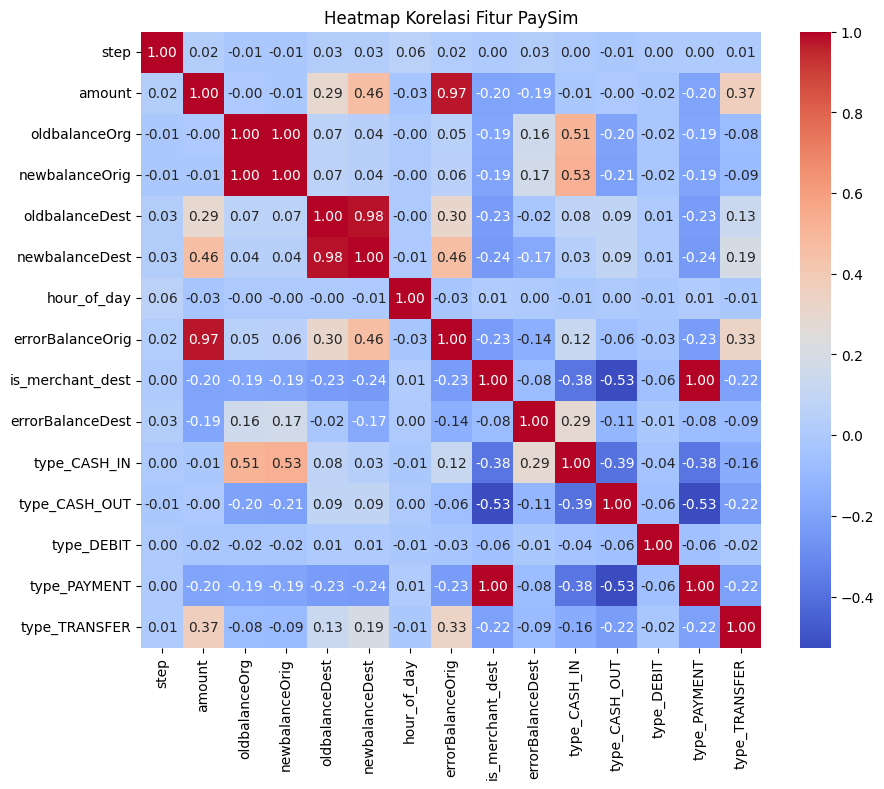

In [15]:
# Membuat Heatmap Korelasi Pearson
plt.figure(figsize=(10, 8))
correlation_matrix = df_encode.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Fitur PaySim")
plt.show()

In [16]:
df_encode = df_encode.drop(columns=['newbalanceDest','newbalanceOrig'])
df_encode.head()

,step,amount,oldbalanceOrg,oldbalanceDest,hour_of_day,errorBalanceOrig,is_merchant_dest,errorBalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.639648,170136.0,0.0,1,0.0,1,0.0,0,0,0,1,0
1,1,1864.280029,21249.0,0.0,1,0.0,1,0.0,0,0,0,1,0
2,1,181.000000,181.0,0.0,1,0.0,0,181.0,0,0,0,0,1
3,1,181.000000,181.0,21182.0,1,0.0,0,21363.0,0,1,0,0,0
4,1,11668.139648,41554.0,0.0,1,0.0,1,0.0,0,0,0,1,0


In [17]:
df_encode = df_encode.drop(columns=['is_merchant_dest'])

### 2.Scalling Numerik (untuk clustering K-Means)


In [18]:
from sklearn.preprocessing import RobustScaler

In [19]:
num_cols = ['amount', 'oldbalanceOrg', 'oldbalanceDest', 'errorBalanceOrig', 'errorBalanceDest']
df_num = df_encode[num_cols]

scaler = RobustScaler()
df_num_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=num_cols, index=df_num.index)

In [20]:
df_num_scaled

,amount,oldbalanceOrg,oldbalanceDest,errorBalanceOrig,errorBalanceDest
0,-0.332932,1.452991,-0.140722,-0.278398,0.0
1,-0.373762,0.065610,-0.140722,-0.278398,0.0
2,-0.382380,-0.130708,-0.140722,-0.278398,1448.0
3,-0.382380,-0.130708,-0.118260,-0.278398,170904.0
4,-0.323571,0.254820,-0.140722,-0.278398,0.0
...,...,...,...,...,...
6362615,1.355693,3.032881,-0.140722,-0.278398,0.0
6362616,31.927898,58.679504,-0.140722,-0.278398,50491276.0
6362617,31.927898,58.679504,-0.068096,-0.278398,4.0
6362618,3.968274,7.788223,-0.140722,-0.278398,6800020.0


In [21]:
df_encode.columns

Index(['step', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'hour_of_day',
       'errorBalanceOrig', 'errorBalanceDest', 'type_CASH_IN', 'type_CASH_OUT',
       'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')

In [22]:
#concat hasil scalling dan categorikal fitur
df_final = pd.concat([df_num_scaled,df_encode[[
    'hour_of_day','type_CASH_IN', 'type_CASH_OUT',
       'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
]], axis=1)

### 3.Binning 

In [23]:
df_encode['balance_drain_ratio'] = np.where(
    df_encode['oldbalanceOrg'] > 0, 
    df_encode['amount'] / df_encode['oldbalanceOrg'], 
    0
)

In [24]:
bins_time = [-1, 6, 18, 24]
labels_time = ['Midnight_to_Morning', 'Working_Hours', 'Evening']
df_encode['time_segment'] = pd.cut(df_encode['hour_of_day'], bins=bins_time, labels=labels_time)

In [25]:
labels_amount = ['Low_Amount', 'Medium_Amount', 'High_Amount']

# q=3 artinya kita membelah data menjadi 3 bagian berdasarkan persentilnya (Kuartil 3 / Tertiles)
df_encode['amount_category'], bin_edges = pd.qcut(df_encode['amount'], q=3, labels=labels_amount, retbins=True)

In [26]:
df_encode.columns

Index(['step', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'hour_of_day',
       'errorBalanceOrig', 'errorBalanceDest', 'type_CASH_IN', 'type_CASH_OUT',
       'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'balance_drain_ratio',
       'time_segment', 'amount_category'],
      dtype='object')

In [27]:
df_encode.to_parquet("/content/drive/MyDrive/Data Mining/Data/Processed/dataset_for_profiling.parquet", index=False)

In [28]:
df_final.to_parquet("/content/drive/MyDrive/Data Mining/Data/Processed/dataset_for_clustering.parquet", index=False)

1. One-Hot Encoding untuk Fitur Kategorikal (type)
Mengubah nilai teks pada kolom type (seperti TRANSFER, CASH_OUT) menjadi matriks biner (0 dan 1) menggunakan pd.get_dummies dengan tipe data int8.
2. Reduksi Dimensi (Dropping Columns)
Tindakan: Membuang fitur nameOrig, nameDest, newbalanceDest, dan newbalanceOrig.
3. Robust Scaling pada Fitur Numerik
Tindakan: Melakukan penskalaan data numerik (amount, oldbalanceOrg, dll.) menggunakan RobustScaler dari Scikit-Learn.
4. Feature Engineering (Pembuatan Fitur Rasio & Binning)
Tindakan: Membuat balance_drain_ratio (Rasio Pengurasan Saldo) serta melakukan diskritisasi (binning) pada waktu transaksi (time_segment) dan nominal transaksi (amount_category).


Fase Preprocessing (DE2) telah berhasil mentransformasi dataset PaySim menjadi format numerik yang teroptimasi penuh untuk algoritma berbasis jarak seperti K-Means. Langkah krusial ini dicapai melalui penerapan One-Hot Encoding berformat int8 pada fitur kategorikal untuk mencegah bias hierarki matematis dan menghemat memori, dipadukan dengan Robust Scaling yang mampu menormalisasi rentang data tanpa menghilangkan sinyal penting dari outlier ekstrem. Proses ini juga secara presisi mereduksi noise dengan menghapus kolom ID ber-entropi tinggi guna menghindari Curse of Dimensionality, serta membuang fitur dengan multikolinearitas ekstrem agar perhitungan jarak antar data tidak mengalami pembobotan ganda (double-weighting) yang dapat mendistorsi sentroid cluster.

Selain optimalisasi matematis, kualitas data turut diperkaya melalui feature engineering yang difokuskan pada pemodelan perilaku. Pembuatan fitur balance_drain_ratio serta diskritisasi (binning) pada waktu dan nominal transaksi secara efektif menerjemahkan angka berkelanjutan menjadi kategori kontekstual yang tajam untuk mendeteksi niat penipuan. Secara keseluruhan, transformasi komprehensif—mulai dari pembersihan noise, penyesuaian skala, hingga pengayaan fitur perilaku—telah menghasilkan dataset yang efisien secara dimensi dan berstatus data-ready, sehingga sepenuhnya matang untuk langsung dieksekusi ke tahap pemodelan segmentasi.